# Fantasy Stat Investigation

This notebook consolidates the old `r_investigation.py`, `sb_investigation.py`, and `k_investigation.py` scripts into one repeatable workflow for all standard 5x5 fantasy categories.

It keeps the original process:

- scrape Fangraphs player data for a date window
- clean numeric columns
- apply category-specific eligibility filters
- summarize each category by year
- compute correlations against likely driver stats
- list the top players by the most correlated driver stats
- plot distributions and year-to-year correlation patterns

The main upgrade is that the category/year loops are data-driven, so adding a new stat is just another entry in `STAT_SPECS`.


In [1]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mlbstatscraping as ss

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)


## Configuration

In [2]:
YEARS = ["2019", "2020", "2021", "2022", "2023"]
SEASON_START = "03-20"
HITTER_END = "09-18"
PITCHER_END = "08-14"

MIN_HITTER_PA = 100
MIN_PITCHER_GAMES = 5
MIN_PITCHER_IP = 30
TOP_N = 5

LOWER_IS_BETTER_COLUMNS = {"ERA", "WHIP", "FIP", "xFIP", "SIERA", "BB_per_9", "HR_per_9"}


## Category Specs

`target` is the stat being investigated. `drivers` are candidate explanatory stats; missing columns are skipped automatically, which keeps the notebook usable across different Fangraphs response shapes.


In [3]:
STAT_SPECS = [
    {
        "label": "R",
        "playertype": "hitting",
        "target": "R",
        "end_month_day": HITTER_END,
        "eligibility": "hitter",
        "drivers": ["PA", "AB", "H", "1B", "2B", "3B", "HR", "RBI", "SB", "BB", "SO", "AVG", "OBP", "SLG", "BABIP"],
    },
    {
        "label": "HR",
        "playertype": "hitting",
        "target": "HR",
        "end_month_day": HITTER_END,
        "eligibility": "hitter",
        "drivers": ["PA", "AB", "H", "2B", "3B", "R", "RBI", "BB", "SO", "AVG", "OBP", "SLG", "GB", "FB", "LD"],
    },
    {
        "label": "RBI",
        "playertype": "hitting",
        "target": "RBI",
        "end_month_day": HITTER_END,
        "eligibility": "hitter",
        "drivers": ["PA", "AB", "H", "1B", "2B", "3B", "HR", "R", "BB", "SO", "AVG", "OBP", "SLG", "BABIP"],
    },
    {
        "label": "SB",
        "playertype": "hitting",
        "target": "SB",
        "end_month_day": HITTER_END,
        "eligibility": "hitter",
        "drivers": ["PA", "AB", "H", "1B", "2B", "3B", "HR", "R", "BB", "CS", "AVG", "OBP", "BABIP"],
    },
    {
        "label": "AVG",
        "playertype": "hitting",
        "target": "AVG",
        "end_month_day": HITTER_END,
        "eligibility": "hitter",
        "drivers": ["PA", "AB", "H", "1B", "2B", "3B", "HR", "R", "RBI", "BB", "SO", "OBP", "SLG", "BABIP"],
    },
    {
        "label": "W",
        "playertype": "pitching",
        "target": "W",
        "end_month_day": PITCHER_END,
        "eligibility": "starter",
        "drivers": ["IP", "TBF", "SO", "ERA", "WHIP", "K_per_9", "BB_per_9", "HR_per_9", "H_per_9", "GS", "G"],
    },
    {
        "label": "SO",
        "playertype": "pitching",
        "target": "SO",
        "end_month_day": PITCHER_END,
        "eligibility": "starter",
        "drivers": ["IP", "TBF", "W", "ERA", "WHIP", "K_per_9", "BB_per_9", "HR_per_9", "H_per_9", "GS", "G"],
    },
    {
        "label": "SV",
        "playertype": "pitching",
        "target": "SV",
        "end_month_day": PITCHER_END,
        "eligibility": "all_pitchers",
        "drivers": ["IP", "TBF", "SO", "ERA", "WHIP", "K_per_9", "BB_per_9", "HR_per_9", "HLD", "BS", "G"],
    },
    {
        "label": "ERA",
        "playertype": "pitching",
        "target": "ERA",
        "end_month_day": PITCHER_END,
        "eligibility": "ip_minimum",
        "lower_is_better": True,
        "drivers": ["IP", "TBF", "W", "SO", "WHIP", "K_per_9", "BB_per_9", "HR_per_9", "H_per_9", "GS", "G"],
    },
    {
        "label": "WHIP",
        "playertype": "pitching",
        "target": "WHIP",
        "end_month_day": PITCHER_END,
        "eligibility": "ip_minimum",
        "lower_is_better": True,
        "drivers": ["IP", "TBF", "W", "SO", "ERA", "K_per_9", "BB_per_9", "HR_per_9", "H_per_9", "GS", "G"],
    },
]


## Data Helpers

In [4]:
def date_for_year(year, month_day):
    return f"{year}-{month_day}"


def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def coerce_numeric_columns(df):
    frame = df.copy()
    for column in frame.columns:
        if column not in {"Name", "Team"}:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


def load_fangraphs_window(playertype, years, end_month_day):
    frames = []
    for year in years:
        frame = ss.get_fangraphs_data(
            playertype,
            [str(year)],
            daystart=date_for_year(year, SEASON_START),
            dayend=date_for_year(year, end_month_day),
            advanced=True,
        )
        frame["Year"] = str(year)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


def add_hitter_features(df):
    frame = coerce_numeric_columns(df)

    if "1B" not in frame.columns and {"H", "2B", "3B", "HR"}.issubset(frame.columns):
        frame["1B"] = frame["H"] - frame["2B"] - frame["3B"] - frame["HR"]
    if "AVG" not in frame.columns and {"H", "AB"}.issubset(frame.columns):
        frame["AVG"] = safe_divide(frame["H"], frame["AB"])
    if "OBP" not in frame.columns and {"H", "BB", "HBP", "AB", "SF"}.issubset(frame.columns):
        frame["OBP"] = safe_divide(frame["H"] + frame["BB"] + frame["HBP"], frame["AB"] + frame["BB"] + frame["HBP"] + frame["SF"])
    if "SLG" not in frame.columns and {"1B", "2B", "3B", "HR", "AB"}.issubset(frame.columns):
        total_bases = frame["1B"] + 2 * frame["2B"] + 3 * frame["3B"] + 4 * frame["HR"]
        frame["SLG"] = safe_divide(total_bases, frame["AB"])
    if "BABIP" not in frame.columns and {"H", "HR", "AB", "SO", "SF"}.issubset(frame.columns):
        frame["BABIP"] = safe_divide(frame["H"] - frame["HR"], frame["AB"] - frame["SO"] - frame["HR"] + frame["SF"])

    return frame.replace([np.inf, -np.inf], np.nan)


def add_pitcher_features(df):
    frame = coerce_numeric_columns(df)

    if "WHIP" not in frame.columns and {"BB", "H", "IP"}.issubset(frame.columns):
        frame["WHIP"] = safe_divide(frame["BB"] + frame["H"], frame["IP"])
    if {"SO", "IP"}.issubset(frame.columns):
        frame["K_per_9"] = 9 * safe_divide(frame["SO"], frame["IP"])
    if {"BB", "IP"}.issubset(frame.columns):
        frame["BB_per_9"] = 9 * safe_divide(frame["BB"], frame["IP"])
    if {"HR", "IP"}.issubset(frame.columns):
        frame["HR_per_9"] = 9 * safe_divide(frame["HR"], frame["IP"])
    if {"H", "IP"}.issubset(frame.columns):
        frame["H_per_9"] = 9 * safe_divide(frame["H"], frame["IP"])

    return frame.replace([np.inf, -np.inf], np.nan)


## Analysis Helpers

In [5]:
def apply_eligibility(df, eligibility):
    frame = df.copy()

    if eligibility == "hitter":
        return frame.loc[frame["PA"] > MIN_HITTER_PA].copy()
    if eligibility == "starter":
        return frame.loc[(frame["G"] < frame["GS"] + 2) & (frame["G"] > MIN_PITCHER_GAMES)].copy()
    if eligibility == "ip_minimum":
        return frame.loc[frame["IP"] >= MIN_PITCHER_IP].copy()
    if eligibility == "all_pitchers":
        return frame.loc[frame["G"] > MIN_PITCHER_GAMES].copy()

    raise ValueError(f"Unknown eligibility rule: {eligibility}")


def available_columns(df, columns):
    return [column for column in columns if column in df.columns]


def summarize_category(frame, spec):
    target = spec["target"]
    lower_is_better = spec.get("lower_is_better", False)
    exposure_column = "PA" if spec["playertype"] == "hitting" else "IP"

    summaries = []
    for year, year_df in frame.groupby("Year"):
        target_series = year_df[target].dropna()
        if target_series.empty:
            continue

        best_value = target_series.min() if lower_is_better else target_series.max()
        best_names = year_df.loc[year_df[target] == best_value, "Name"].dropna().tolist()

        summaries.append(
            {
                "stat": spec["label"],
                "year": str(year),
                "players": len(year_df),
                "exposure": year_df[exposure_column].sum() if exposure_column in year_df else np.nan,
                "target_sum": target_series.sum() if not lower_is_better else np.nan,
                "target_mean": target_series.mean(),
                "target_median": target_series.median(),
                "best_value": best_value,
                "best_players": ", ".join(best_names[:5]),
            }
        )

    return pd.DataFrame(summaries)


def correlation_table(frame, spec):
    target = spec["target"]
    drivers = [column for column in available_columns(frame, spec["drivers"]) if column != target]

    rows = []
    for year, year_df in frame.groupby("Year"):
        for driver in drivers:
            subset = year_df[[driver, target]].dropna()
            if len(subset) < 3 or subset[driver].nunique() < 2 or subset[target].nunique() < 2:
                corr = np.nan
            else:
                corr = subset[driver].corr(subset[target])
            rows.append(
                {
                    "stat": spec["label"],
                    "year": str(year),
                    "target": target,
                    "driver": driver,
                    "correlation": corr,
                    "abs_correlation": abs(corr) if pd.notna(corr) else np.nan,
                    "n": len(subset),
                }
            )

    return pd.DataFrame(rows).sort_values(["stat", "year", "abs_correlation"], ascending=[True, True, False])


def top_driver_players(frame, correlations, spec, top_n=TOP_N):
    rows = []
    target = spec["target"]

    best_drivers = (
        correlations.dropna(subset=["correlation"])
        .sort_values(["year", "abs_correlation"], ascending=[True, False])
        .groupby("year")
        .head(3)
    )

    for _, corr_row in best_drivers.iterrows():
        year = corr_row["year"]
        driver = corr_row["driver"]
        year_df = frame.loc[frame["Year"].astype(str) == str(year)].dropna(subset=[driver, target])
        ascending = driver in LOWER_IS_BETTER_COLUMNS
        leaders = year_df.sort_values(driver, ascending=ascending).head(top_n)

        for rank, (_, player) in enumerate(leaders.iterrows(), start=1):
            rows.append(
                {
                    "stat": spec["label"],
                    "year": year,
                    "driver": driver,
                    "driver_correlation": corr_row["correlation"],
                    "rank": rank,
                    "Name": player.get("Name"),
                    "Team": player.get("Team"),
                    "driver_value": player.get(driver),
                    "target_value": player.get(target),
                }
            )

    return pd.DataFrame(rows)


def analyze_stat(frame, spec):
    eligible = apply_eligibility(frame, spec["eligibility"])
    target = spec["target"]
    keep_columns = ["Name", "Team", "Year", target, *spec["drivers"]]
    keep_columns = available_columns(eligible, keep_columns)
    eligible = eligible[keep_columns].dropna(subset=[target]).copy()

    summary = summarize_category(eligible, spec)
    correlations = correlation_table(eligible, spec)
    leaders = top_driver_players(eligible, correlations, spec)

    return eligible, summary, correlations, leaders


## Load Data

In [6]:
hitting_raw = load_fangraphs_window("hitting", YEARS, HITTER_END)
pitching_raw = load_fangraphs_window("pitching", YEARS, PITCHER_END)

hitting = add_hitter_features(hitting_raw)
pitching = add_pitcher_features(pitching_raw)

print(f"Hitting rows: {len(hitting):,}")
print(f"Pitching rows: {len(pitching):,}")
print("Hitting columns:", sorted(hitting.columns.tolist()))
print("Pitching columns:", sorted(pitching.columns.tolist()))


/opt/homebrew/lib/python3.11/site-packages/fangraphs/fangraphsscraper.py:119: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Year'] = year
/opt/homebrew/lib/python3.11/site-packages/fangraphs/fangraphsscraper.py:119: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Year'] = year
/opt/homebrew/lib/python3.11/site-packages/fangraphs/fangraphsscraper.py:119: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

Hitting rows: 7,049
Pitching rows: 3,740
Hitting columns: ['+WPA', '-WPA', '1B', '2B', '3B', 'AB', 'AVG', 'AVG+', 'Age', 'AgeR', 'AsCCorrect%', 'AsCOverturned', 'AsCReview', 'AttackAngle', 'AttackDirection', 'AvgBatSpeed', 'BABIP', 'BABIP+', 'BB', 'BB%', 'BB%+', 'BB/K', 'BCorrect%', 'BOverturned', 'BPTV', 'BReview', 'BTV', 'BU', 'BUH', 'BUH%', 'Balls', 'Barrel%', 'Barrels', 'BaseRunning', 'Bats', 'Batting', 'BlastContact%', 'BlastSwing%', 'C+SwStr%', 'CB%', 'CBv', 'CCorrect%', 'CFraming', 'CH%', 'CHv', 'COverturned', 'CPTV', 'CReview', 'CS', 'CStr%', 'CT%', 'CTv', 'Cent', 'Cent%', 'Cent%+', 'Clutch', 'CompetitiveSwings', 'Contact%', 'DGV', 'DSV', 'Defense', 'DepthInBox', 'DistanceOffPlate', 'Dollars', 'EBV', 'ESV', 'EV', 'EV90', 'Events', 'F-Strike%', 'FB', 'FB%', 'FB%+', 'FB%1', 'FBv', 'FastSwing%', 'Fielding', 'G', 'GB', 'GB%', 'GB%+', 'GB/FB', 'GDP', 'GDPRuns', 'H', 'HBP', 'HR', 'HR/FB', 'HRFB%+', 'Hard', 'Hard%', 'Hard%+', 'HardHit', 'HardHit%', 'IBB', 'IFFB', 'IFFB%', 'IFH', 'IFH%

/var/folders/6w/dlp9742d17v7x08hrlbn3d0r0000gn/T/ipykernel_11432/656207187.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["K_per_9"] = 9 * safe_divide(frame["SO"], frame["IP"])
/var/folders/6w/dlp9742d17v7x08hrlbn3d0r0000gn/T/ipykernel_11432/656207187.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["BB_per_9"] = 9 * safe_divide(frame["BB"], frame["IP"])
/var/folders/6w/dlp9742d17v7x08hrlbn3d0r0000gn/T/ipykernel_11432/656207187.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

## Run All Category Investigations

In [7]:
eligible_frames = {}
summary_frames = []
correlation_frames = []
leader_frames = []

for spec in STAT_SPECS:
    source = hitting if spec["playertype"] == "hitting" else pitching
    eligible, summary, correlations, leaders = analyze_stat(source, spec)

    eligible_frames[spec["label"]] = eligible
    summary_frames.append(summary)
    correlation_frames.append(correlations)
    leader_frames.append(leaders)

summary_df = pd.concat(summary_frames, ignore_index=True)
correlations_df = pd.concat(correlation_frames, ignore_index=True)
leaders_df = pd.concat(leader_frames, ignore_index=True)

summary_df


,stat,year,players,exposure,target_sum,target_mean,target_median,best_value,best_players
0,R,2019,441,162789.0,21124.000000,47.900227,44.000000,131.000000,Mookie Betts
1,R,2020,265,43525.0,5713.000000,21.558491,20.000000,46.000000,Fernando Tatis Jr.
2,R,2021,454,154670.0,19215.000000,42.323789,36.000000,118.000000,Vladimir Guerrero Jr.
3,R,2022,449,156022.0,18022.000000,40.138085,36.000000,122.000000,Aaron Judge
4,R,2023,443,162009.0,19924.000000,44.975169,43.000000,135.000000,Ronald Acuna Jr.
5,HR,2019,441,162789.0,6209.000000,14.079365,12.000000,49.000000,Pete Alonso
6,HR,2020,265,43525.0,1630.000000,6.150943,6.000000,20.000000,Luke Voit
7,HR,2021,454,154670.0,5302.000000,11.678414,8.000000,46.000000,Vladimir Guerrero Jr.
8,HR,2022,449,156022.0,4582.000000,10.204900,8.000000,59.000000,Aaron Judge
9,HR,2023,443,162009.0,5301.000000,11.966140,10.000000,52.000000,Matt Olson


## Category Summaries

In [8]:
summary_df.sort_values(["stat", "year"])


,stat,year,players,exposure,target_sum,target_mean,target_median,best_value,best_players
20,AVG,2019,441,162789.0,110.633146,0.250869,0.252174,0.349153,Luis Arraez
21,AVG,2020,265,43525.0,67.224802,0.253678,0.250000,0.372093,Jose Iglesias
22,AVG,2021,454,154670.0,109.445854,0.241070,0.245429,0.350427,Luis Robert Jr.
23,AVG,2022,449,156022.0,106.984326,0.238272,0.238095,0.330961,Freddie Freeman
24,AVG,2023,443,162009.0,107.953737,0.243688,0.246753,0.354497,Luis Arraez
38,ERA,2019,390,28011.6,NaN,4.379386,4.297838,1.125000,Kirby Yates
39,ERA,2020,2,62.3,NaN,1.583875,1.583875,1.113402,Lance Lynn
40,ERA,2021,391,26109.8,NaN,4.052996,3.857143,0.915254,Kendall Graveman
41,ERA,2022,393,25890.2,NaN,3.827934,3.705883,0.924658,Ryan Helsley
42,ERA,2023,399,27213.0,NaN,4.096604,3.983608,0.864000,Josh Hader


## Strongest Correlations

In [9]:
strongest_correlations = (
    correlations_df.dropna(subset=["correlation"])
    .sort_values(["stat", "year", "abs_correlation"], ascending=[True, True, False])
    .groupby(["stat", "year"])
    .head(8)
    .reset_index(drop=True)
)

strongest_correlations


,stat,year,target,driver,correlation,abs_correlation,n
0,AVG,2019,AVG,OBP,0.783197,0.783197,441
1,AVG,2019,AVG,BABIP,0.783176,0.783176,441
2,AVG,2019,AVG,SLG,0.731469,0.731469,441
3,AVG,2019,AVG,1B,0.655251,0.655251,441
4,AVG,2019,AVG,H,0.654386,0.654386,441
...,...,...,...,...,...,...,...
363,WHIP,2023,WHIP,HR_per_9,0.363572,0.363572,399
364,WHIP,2023,WHIP,K_per_9,-0.279357,0.279357,399
365,WHIP,2023,WHIP,W,-0.259343,0.259343,399
366,WHIP,2023,WHIP,G,-0.244045,0.244045,399


In [10]:
correlation_pivot = strongest_correlations.pivot_table(
    index=["stat", "driver"],
    columns="year",
    values="correlation",
    aggfunc="mean",
)

correlation_pivot


year              2019      2020      2021      2022      2023
stat driver                                                   
AVG  1B       0.655251  0.692480  0.659578  0.650553  0.652819
     2B       0.591688  0.498015  0.570658  0.560792  0.587735
     BABIP    0.783176  0.811965  0.792465  0.791536  0.769925
     H        0.654386  0.716360  0.640853  0.630690  0.643686
     OBP      0.783197  0.765201  0.804155  0.821601  0.772907
...                ...       ...       ...       ...       ...
WHIP H_per_9  0.822920       NaN  0.778770  0.833727  0.786799
     IP            NaN       NaN -0.166819       NaN       NaN
     K_per_9 -0.284403       NaN -0.314786 -0.348664 -0.279357
     SO      -0.297278       NaN -0.302586 -0.263824 -0.194367
     W       -0.292018       NaN -0.328810 -0.278434 -0.259343

[90 rows x 5 columns]

## Top Players By Strongest Driver Stats

In [11]:
leaders_df.sort_values(["stat", "year", "driver", "rank"])


,stat,year,driver,driver_correlation,rank,Name,Team,driver_value,target_value
305,AVG,2019,BABIP,0.783176,1,Donovan Solano,SFG,0.412500,0.336538
306,AVG,2019,BABIP,0.783176,2,Fernando Tatis Jr.,SDP,0.409756,0.317365
307,AVG,2019,BABIP,0.783176,3,Yoan Moncada,CHW,0.402556,0.311715
308,AVG,2019,BABIP,0.783176,4,Tim Anderson,CHW,0.398860,0.335470
309,AVG,2019,BABIP,0.783176,5,Nick Solak,TEX,0.396825,0.308511
...,...,...,...,...,...,...,...,...,...
675,WHIP,2023,H_per_9,0.786799,1,Adam Wainwright,STL,15.362538,2.085000
676,WHIP,2023,H_per_9,0.786799,2,Nick Lodolo,CIN,13.196481,1.747573
677,WHIP,2023,H_per_9,0.786799,3,Luis Severino,NYY,13.101266,1.884817
678,WHIP,2023,H_per_9,0.786799,4,Kyle Muller,OAK,12.980769,1.961538


## Distribution Plots

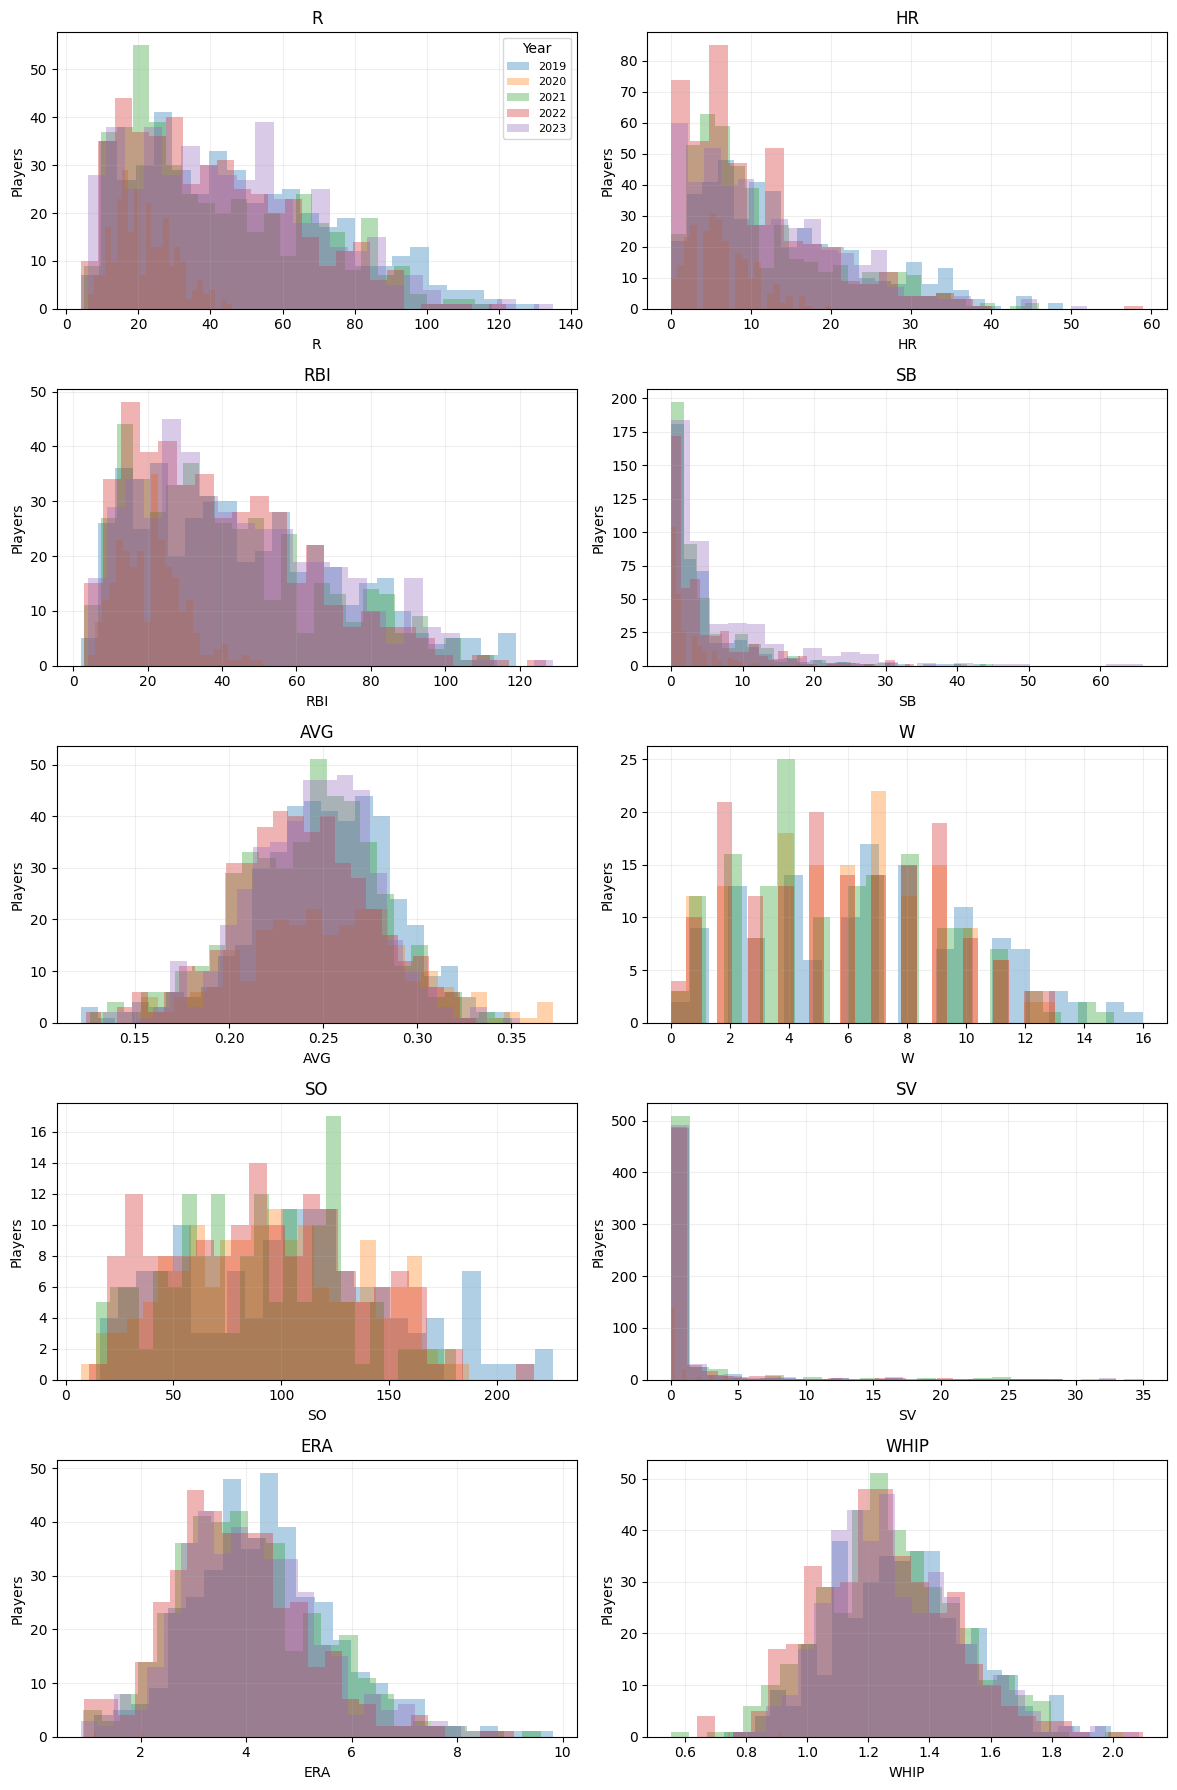

In [12]:
fig, axes = plt.subplots(5, 2, figsize=(12, 18))
axes = axes.ravel()

for ax, spec in zip(axes, STAT_SPECS):
    frame = eligible_frames[spec["label"]]
    target = spec["target"]
    for year, year_df in frame.groupby("Year"):
        ax.hist(year_df[target].dropna(), bins=25, alpha=0.35, label=str(year))
    ax.set_title(spec["label"])
    ax.set_xlabel(target)
    ax.set_ylabel("Players")
    ax.grid(alpha=0.2)

axes[0].legend(title="Year", fontsize=8)
fig.tight_layout()


## Correlation Heatmap

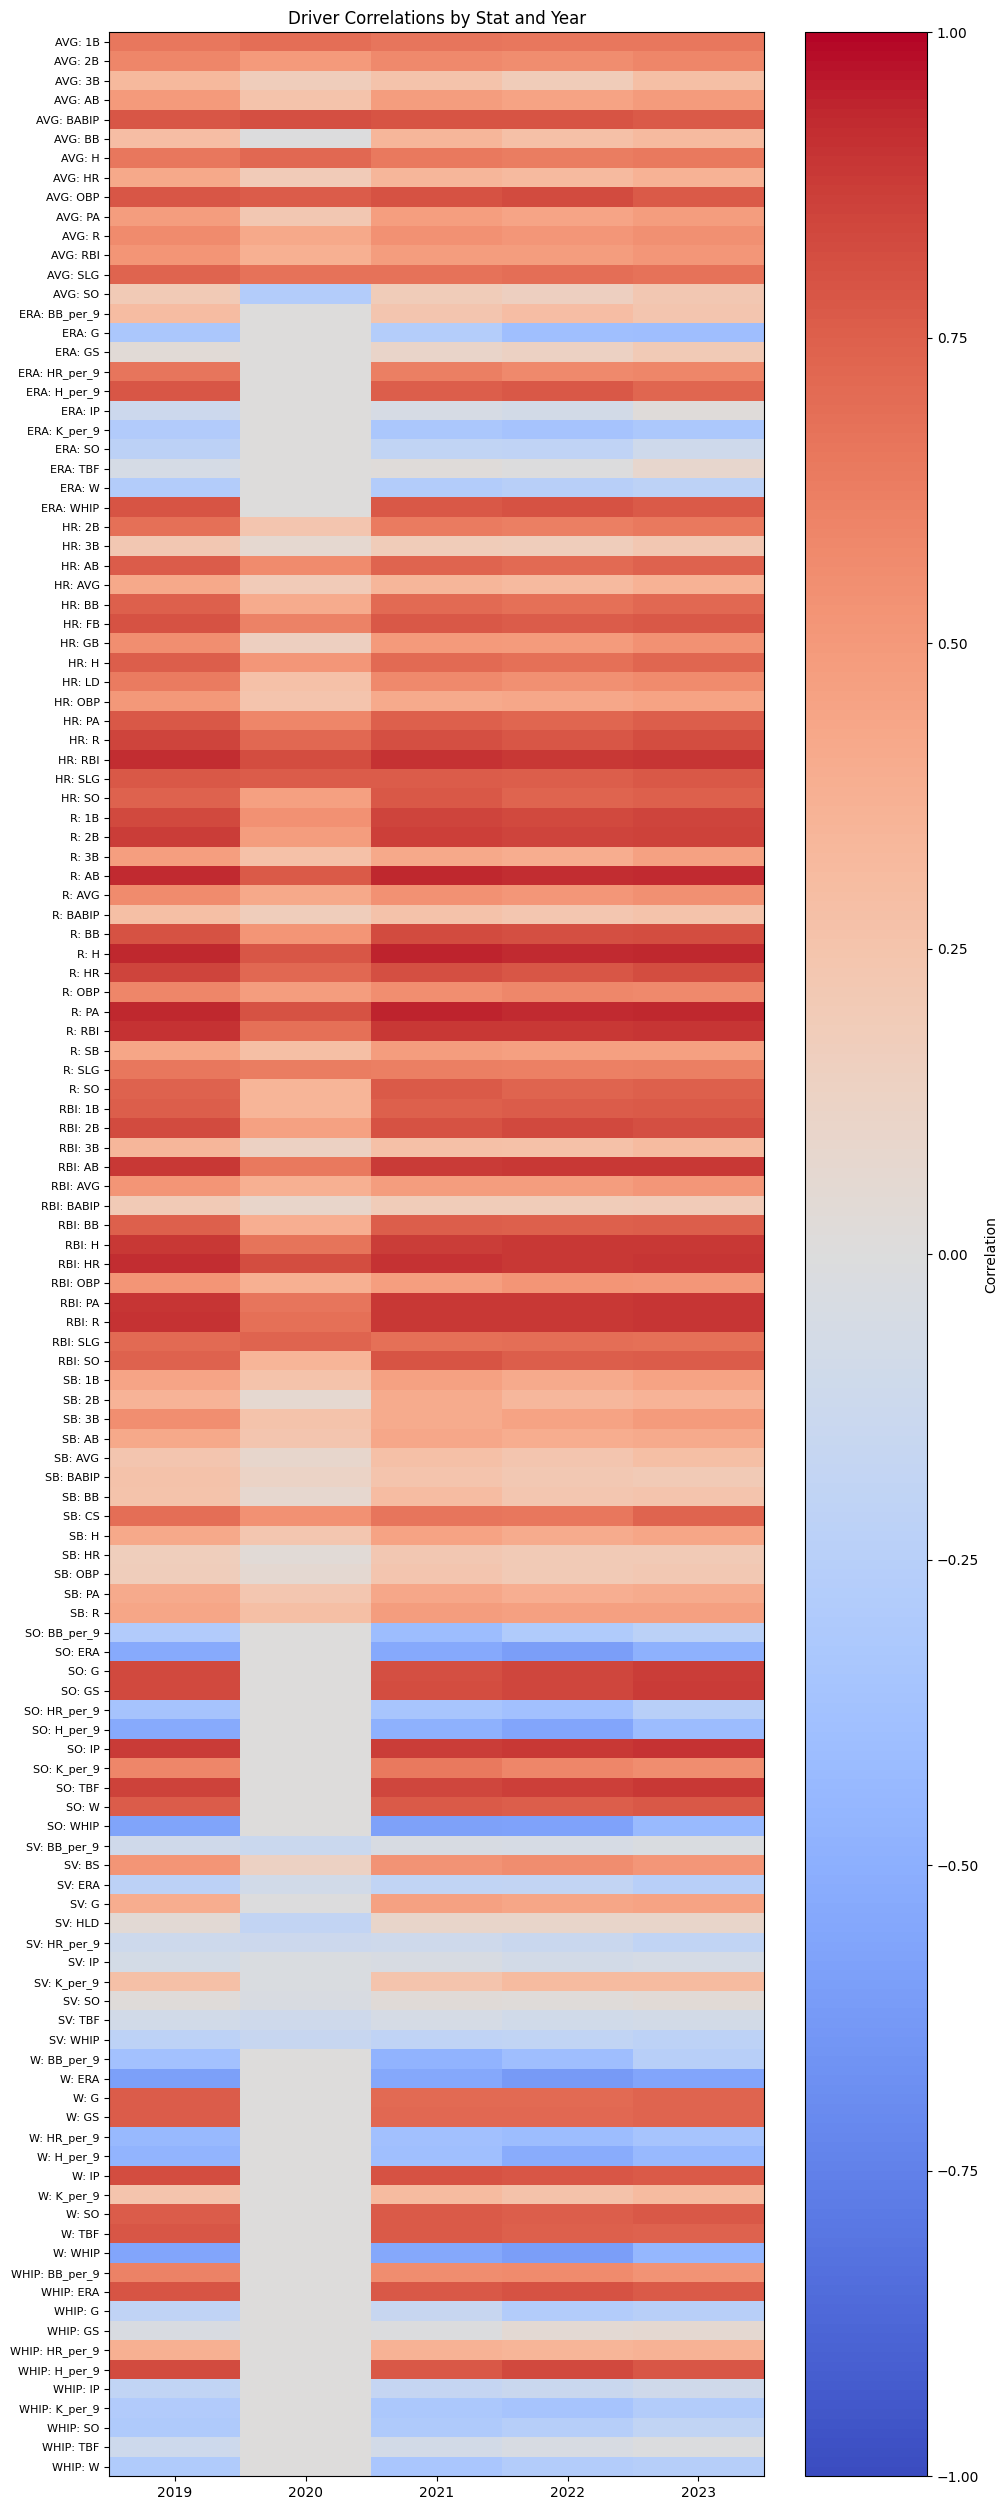

In [13]:
heatmap_data = (
    correlations_df.dropna(subset=["correlation"])
    .sort_values(["stat", "driver", "year"])
    .pivot_table(index=["stat", "driver"], columns="year", values="correlation")
)

fig, ax = plt.subplots(figsize=(10, max(8, len(heatmap_data) * 0.20)))
image = ax.imshow(heatmap_data.fillna(0), aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([f"{stat}: {driver}" for stat, driver in heatmap_data.index], fontsize=8)
ax.set_title("Driver Correlations by Stat and Year")
fig.colorbar(image, ax=ax, label="Correlation")
fig.tight_layout()


## Inspect One Stat

In [14]:
STAT_TO_INSPECT = "SO"

print("Summary")
display(summary_df.loc[summary_df["stat"] == STAT_TO_INSPECT].sort_values("year"))

print("Strongest correlations")
display(
    correlations_df.loc[correlations_df["stat"] == STAT_TO_INSPECT]
    .dropna(subset=["correlation"])
    .sort_values(["year", "abs_correlation"], ascending=[True, False])
    .groupby("year")
    .head(10)
)

print("Top driver players")
display(leaders_df.loc[leaders_df["stat"] == STAT_TO_INSPECT].sort_values(["year", "driver", "rank"]))


Summary


,stat,year,players,exposure,target_sum,target_mean,target_median,best_value,best_players
29,SO,2019,135,14349.8,14026.0,103.896296,107.0,226.0,Gerrit Cole
30,SO,2021,152,14556.1,14435.0,94.967105,94.0,187.0,Zack Wheeler
31,SO,2022,154,14648.3,13460.0,87.402597,88.0,181.0,Corbin Burnes
32,SO,2023,162,15461.3,14769.0,91.166667,91.0,217.0,Spencer Strider


Strongest correlations


,stat,year,target,driver,correlation,abs_correlation,n
399,SO,2019,SO,IP,0.878089,0.878089,135
400,SO,2019,SO,TBF,0.852156,0.852156,135
401,SO,2019,SO,GS,0.832205,0.832205,135
402,SO,2019,SO,G,0.829605,0.829605,135
403,SO,2019,SO,W,0.760182,0.760182,135
404,SO,2019,SO,K_per_9,0.590703,0.590703,135
405,SO,2019,SO,WHIP,-0.563076,0.563076,135
406,SO,2019,SO,ERA,-0.530938,0.530938,135
407,SO,2019,SO,H_per_9,-0.524538,0.524538,135
408,SO,2019,SO,HR_per_9,-0.354757,0.354757,135


Top driver players


,stat,year,driver,driver_correlation,rank,Name,Team,driver_value,target_value
445,SO,2019,GS,0.832205,1,Trevor Bauer,- - -,27.0,204.0
446,SO,2019,GS,0.832205,2,Brad Keller,KCR,26.0,117.0
447,SO,2019,GS,0.832205,3,German Marquez,COL,26.0,163.0
448,SO,2019,GS,0.832205,4,Marco Gonzales,SEA,26.0,116.0
449,SO,2019,GS,0.832205,5,Aaron Nola,PHI,26.0,173.0
435,SO,2019,IP,0.878089,1,Trevor Bauer,- - -,172.2,204.0
436,SO,2019,IP,0.878089,2,German Marquez,COL,163.0,163.0
437,SO,2019,IP,0.878089,3,Justin Verlander,HOU,162.2,217.0
438,SO,2019,IP,0.878089,4,Shane Bieber,CLE,162.1,200.0
439,SO,2019,IP,0.878089,5,Lance Lynn,TEX,160.0,184.0


## Easy Next Experiments

- Change `HITTER_END` and `PITCHER_END` to compare early-season versus late-season signals.
- Add advanced Fangraphs columns to any spec's `drivers` list; missing columns will be skipped.
- Split pitcher categories by role, for example starters for wins and strikeouts, relievers for saves and ratios.
- Save `summary_df`, `correlations_df`, and `leaders_df` to CSV if you want static artifacts for reports.
